# TP5 AA1 Clasificación

**Nombre completo:** Corina Arreguez

## Dataset elegido
Para este trabajo práctico se eligió el dataset **Dry Bean Dataset** del repositorio UCI Machine Learning Repository.

El objetivo del trabajo es aplicar modelos de clasificación para predecir el tipo de poroto seco a partir de características geométricas extraídas de imágenes.

## 1. Selección del Dataset

El dataset elegido es **Dry Bean Dataset**.

Este dataset contiene mediciones de distintos granos de porotos secos. A partir de imágenes de los granos se extrajeron características de forma, tamaño, perímetro, redondez, compacidad, entre otras.

La variable objetivo es **Class**, que representa el tipo de poroto. Las clases posibles son:

- SEKER
- BARBUNYA
- BOMBAY
- CALI
- DERMASON
- HOROZ
- SIRA

Se trata de un problema de **clasificación multiclase**, ya que el modelo debe predecir una de varias categorías posibles.

In [2]:
# Instalación
!pip -q install openpyxl imbalanced-learn

In [3]:
# Importación de librerías

import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
# Carga del dataset

zip_path = "dry+bean+dataset.zip"

if not os.path.exists(zip_path):
    try:
        from google.colab import files
        print("Subí el archivo dry+bean+dataset.zip")
        uploaded = files.upload()
        zip_path = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError("No se encontró el archivo ZIP. Subilo al entorno antes de ejecutar.") from e

extract_dir = "drybean_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# Buscar el archivo Excel dentro de la carpeta extraída
excel_path = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".xlsx"):
            excel_path = os.path.join(root, file)

print("Archivo encontrado:", excel_path)

df = pd.read_excel(excel_path)
df.head()

Subí el archivo dry+bean+dataset.zip


Saving dry+bean+dataset.zip to dry+bean+dataset.zip
Archivo encontrado: drybean_dataset/DryBeanDataset/Dry_Bean_Dataset.xlsx


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
# Dimensiones del dataset
df.shape

(13611, 17)

In [6]:
# Información general de columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

## 2. Análisis exploratorio previo al modelado

En esta sección se analiza el dataset antes de entrenar los modelos. El objetivo es conocer la cantidad de datos, los tipos de variables, la presencia de valores faltantes, la distribución de las clases y posibles relaciones entre variables.

El dataset posee variables numéricas que describen la forma del poroto y una variable categórica objetivo llamada `Class`.

In [7]:
# Primeras filas del dataset
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [8]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


In [9]:
# Verificación de valores faltantes
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


No se observan valores faltantes en las columnas del dataset. Por lo tanto, no es necesario eliminar filas ni imputar datos.

In [10]:
# Distribución de la variable objetivo
class_counts = df["Class"].value_counts()
class_counts

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


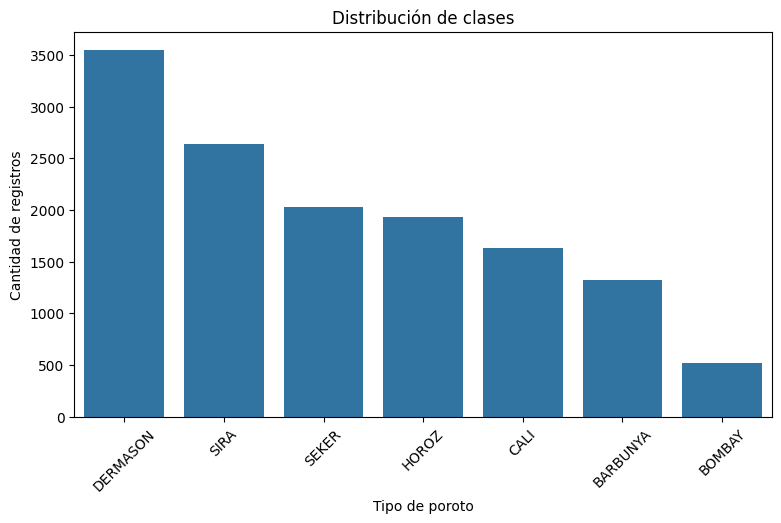

In [11]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="Class", order=class_counts.index)
plt.title("Distribución de clases")
plt.xlabel("Tipo de poroto")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

La distribución de clases no es perfectamente balanceada. La clase **DERMASON** tiene más registros, mientras que **BOMBAY** tiene menos. Esto es importante porque puede afectar el entrenamiento de los modelos y la interpretación de métricas como accuracy. Por eso también se analizarán métricas como precision, recall y F1-score.

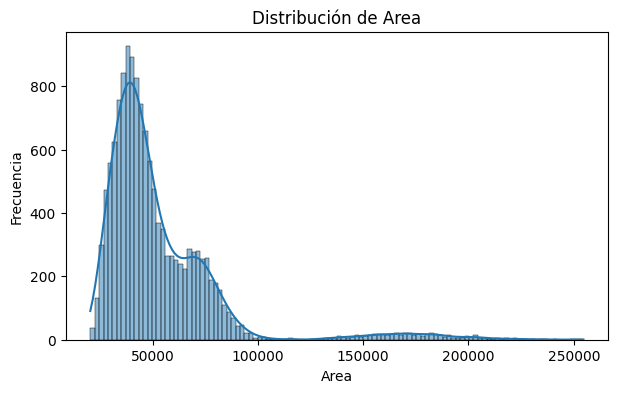

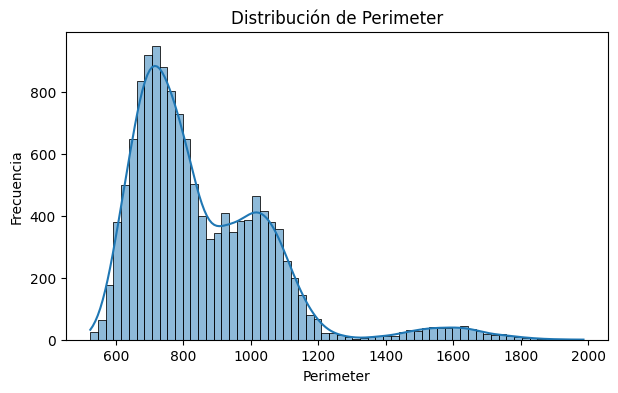

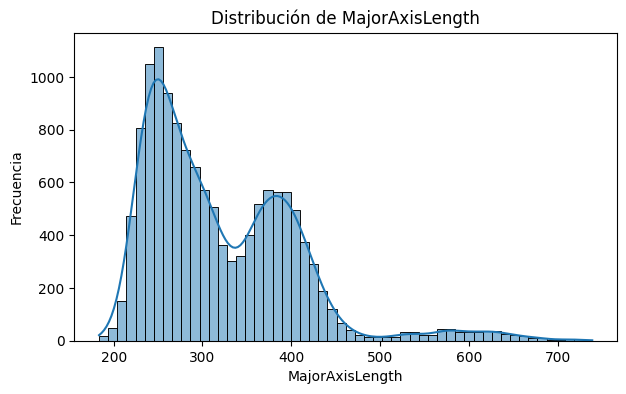

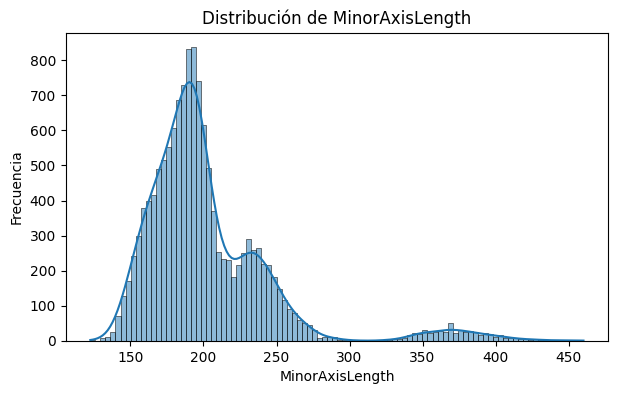

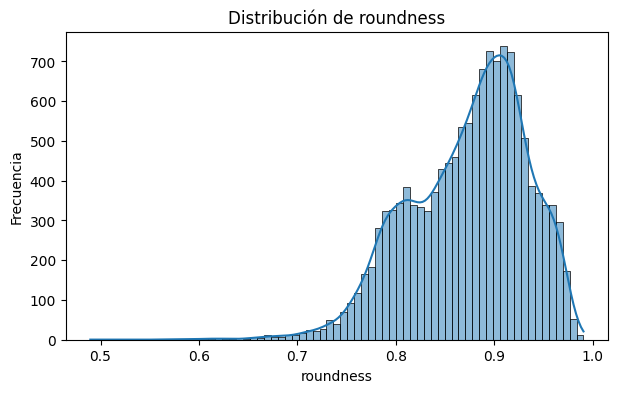

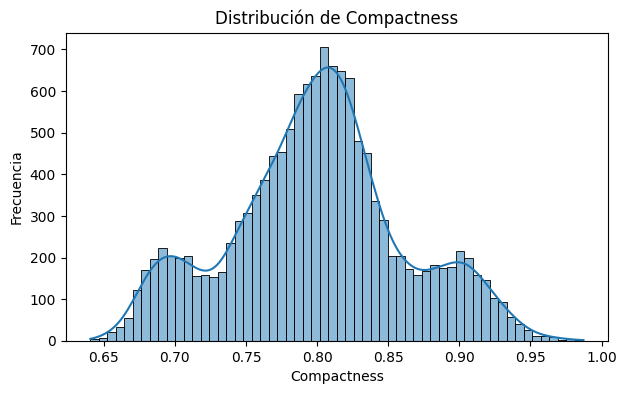

In [12]:
# Histogramas de algunas variables numéricas importantes
features_to_plot = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "roundness", "Compactness"]

for col in features_to_plot:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

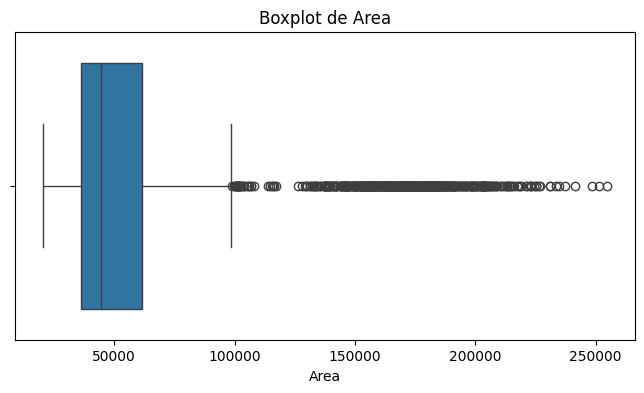

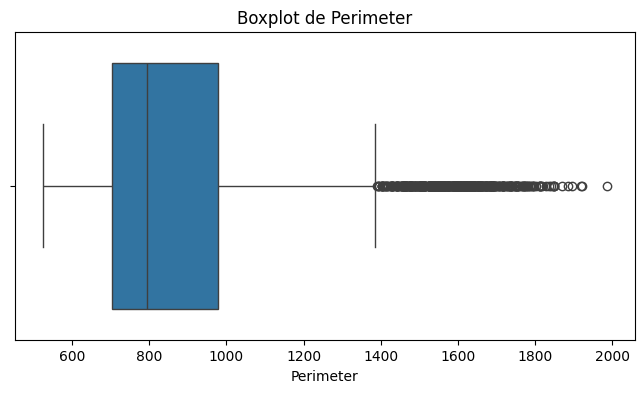

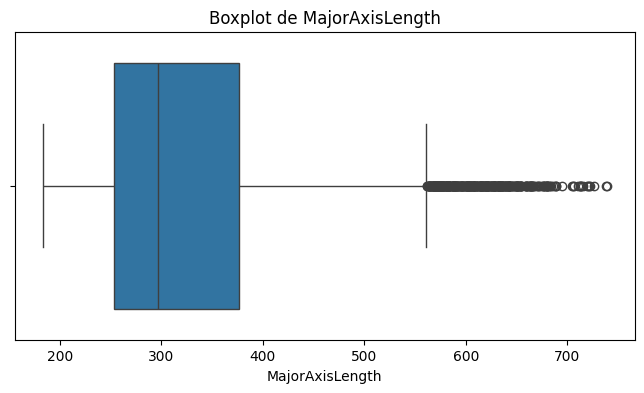

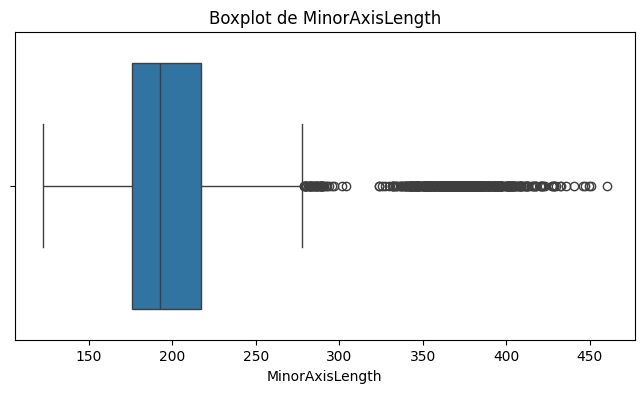

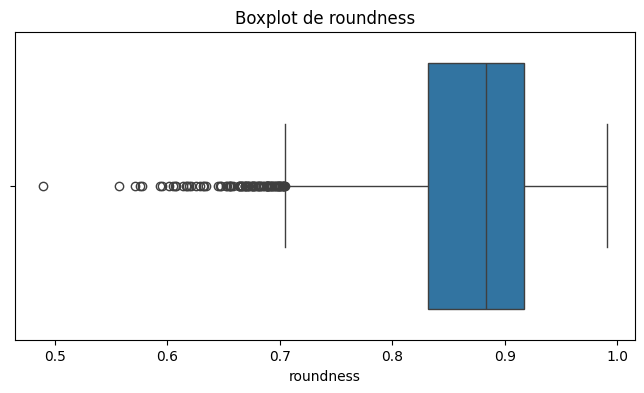

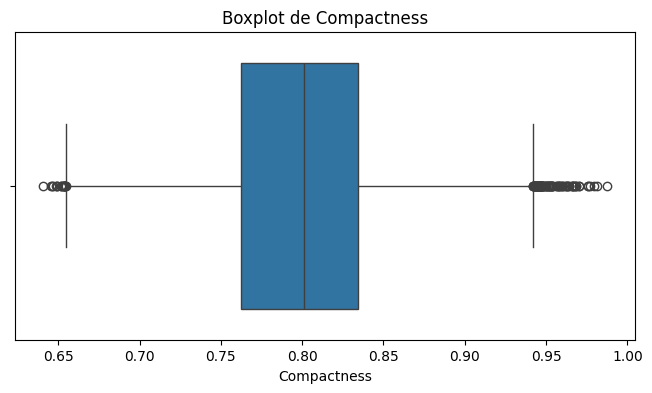

In [13]:
# Boxplots para observar posibles outliers por variable
for col in features_to_plot:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

En los boxplots se observan algunos valores alejados en variables como `Area`, `Perimeter` y `MajorAxisLength`. En este caso no se eliminan automáticamente porque pueden representar porotos reales de mayor tamaño y no necesariamente errores de carga. Además, las diferencias de tamaño y forma pueden ser útiles para distinguir las clases.

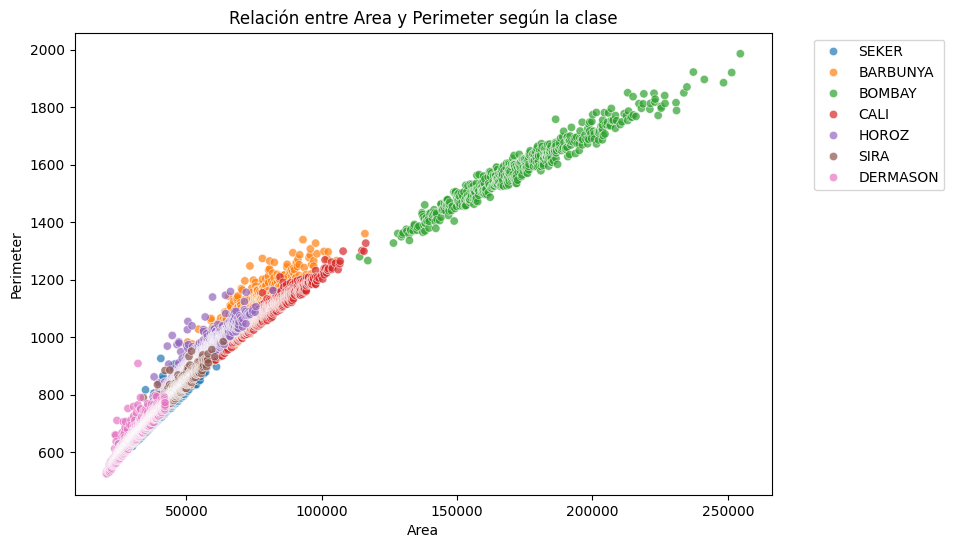

In [14]:
# Relación entre algunas variables y la clase
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Area", y="Perimeter", hue="Class", alpha=0.7)
plt.title("Relación entre Area y Perimeter según la clase")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

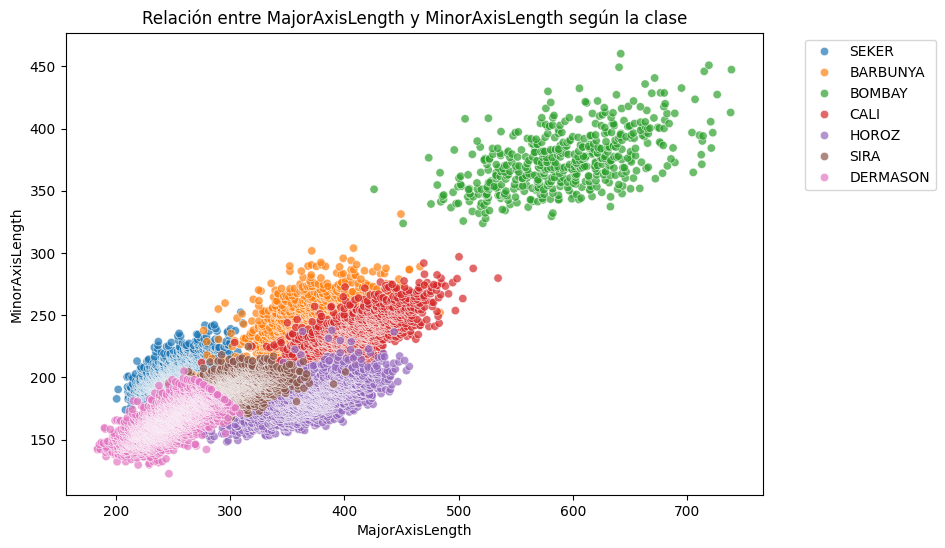

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="MajorAxisLength", y="MinorAxisLength", hue="Class", alpha=0.7)
plt.title("Relación entre MajorAxisLength y MinorAxisLength según la clase")
plt.xlabel("MajorAxisLength")
plt.ylabel("MinorAxisLength")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

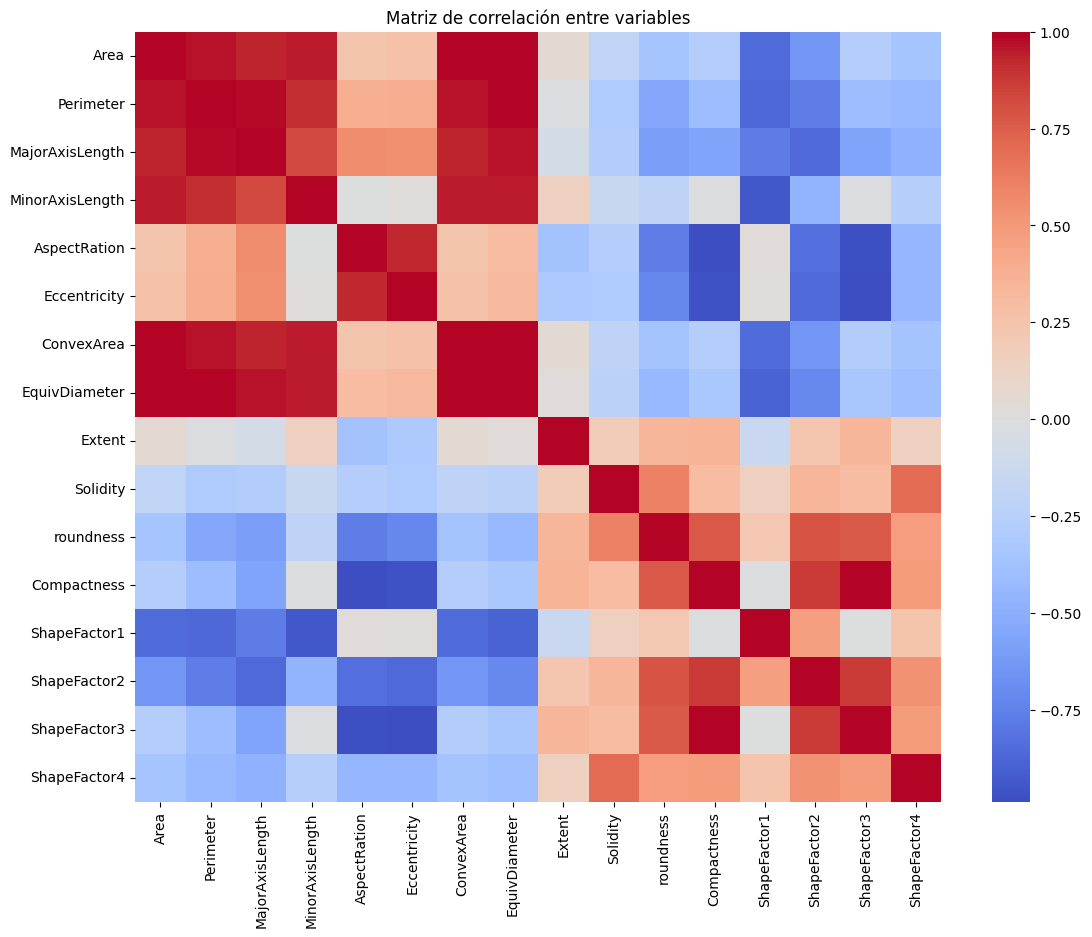

In [16]:
# Mapa de correlación entre variables numéricas
plt.figure(figsize=(13,10))
corr = df.drop(columns=["Class"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables")
plt.show()

A partir de los gráficos de dispersión se observa que algunas clases tienden a agruparse según características como área, perímetro y longitud de los ejes. Esto indica que las variables geométricas pueden ser útiles para clasificar los distintos tipos de porotos.

También se observan correlaciones altas entre algunas variables, por ejemplo entre `Area`, `Perimeter`, `ConvexArea` y `EquivDiameter`. Esto es esperable porque varias características describen aspectos relacionados con el tamaño del grano.

## 3. Preprocesamiento

En esta etapa se prepara el dataset para que pueda ser utilizado por los modelos de clasificación.

Pasos realizados:

1. Separar variables predictoras (`X`) y variable objetivo (`y`).
2. Codificar la variable objetivo con `LabelEncoder`, porque los modelos necesitan valores numéricos.
3. Dividir los datos en entrenamiento y prueba.
4. Escalar las variables numéricas con `StandardScaler`.

No se descartan variables predictoras, porque todas representan características geométricas del poroto y pueden aportar información para la clasificación.

No se utilizan variables categóricas como predictoras, ya que todas las features del dataset son numéricas. La única variable categórica es `Class`, que es el target.

In [17]:
# Separación de variables predictoras y target
X = df.drop(columns=["Class"])
y = df["Class"]

print("Cantidad de variables predictoras:", X.shape[1])
print("Cantidad de instancias:", X.shape[0])
print("Clases:", y.unique())

Cantidad de variables predictoras: 16
Cantidad de instancias: 13611
Clases: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [18]:
# Codificación del target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Equivalencia entre número y clase
class_mapping = pd.DataFrame({
    "Clase original": label_encoder.classes_,
    "Clase codificada": range(len(label_encoder.classes_))
})
class_mapping

,Clase original,Clase codificada
0,BARBUNYA,0
1,BOMBAY,1
2,CALI,2
3,DERMASON,3
4,HOROZ,4
5,SEKER,5
6,SIRA,6


In [19]:
# División entre entrenamiento y prueba
# Se usa stratify para mantener proporciones similares de clases en train y test.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (10888, 16)
Tamaño X_test: (2723, 16)
Tamaño y_train: (10888,)
Tamaño y_test: (2723,)


Se utiliza una división 80% entrenamiento y 20% prueba. Además, se aplica `stratify` para conservar la proporción de clases en ambos conjuntos.

## 4. Clasificación con Logistic Regression

En esta sección se entrena un modelo de **Regresión Logística**. Aunque su nombre incluye la palabra "regresión", en este caso se utiliza como algoritmo de clasificación.

Como las variables tienen escalas diferentes, se utiliza un pipeline que primero aplica `StandardScaler` y luego entrena el modelo.

In [20]:
# Modelo Logistic Regression con escalado
log_reg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

In [21]:
# Predicciones
y_train_pred_lr = log_reg_model.predict(X_train)
y_test_pred_lr = log_reg_model.predict(X_test)

# Métricas
metrics_lr = {
    "Modelo": "Logistic Regression",
    "Accuracy train": accuracy_score(y_train, y_train_pred_lr),
    "Accuracy test": accuracy_score(y_test, y_test_pred_lr),
    "Precision macro test": precision_score(y_test, y_test_pred_lr, average="macro"),
    "Recall macro test": recall_score(y_test, y_test_pred_lr, average="macro"),
    "F1 macro test": f1_score(y_test, y_test_pred_lr, average="macro")
}

pd.DataFrame([metrics_lr])

,Modelo,Accuracy train,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Logistic Regression,0.926249,0.92141,0.935383,0.932149,0.933538


In [22]:
# Reporte de clasificación
print(classification_report(
    y_test,
    y_test_pred_lr,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.89      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.94       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.93      0.95      0.94       406
        SIRA       0.85      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



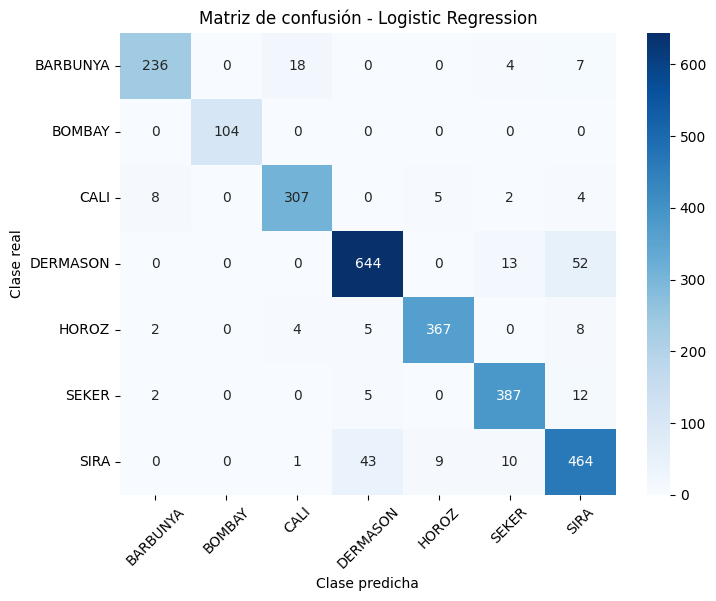

In [23]:
# Matriz de confusión Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Matriz de confusión - Logistic Regression")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Interpretación de Logistic Regression

La Regresión Logística obtiene un buen desempeño general. El accuracy permite ver qué proporción de ejemplos fueron clasificados correctamente. Sin embargo, como el dataset no está perfectamente balanceado, también es importante mirar precision, recall y F1-score por clase.

La matriz de confusión permite observar en qué clases se equivoca más el modelo. Los valores de la diagonal principal representan los aciertos. Los valores fuera de la diagonal muestran confusiones entre tipos de porotos.

## 5. Otro clasificador: KNN

Como segundo modelo se eligió **K-Nearest Neighbors (KNN)**.

La elección se justifica porque el dataset contiene características geométricas de los porotos. Es razonable pensar que porotos de la misma clase tengan formas y tamaños similares, por lo que un modelo basado en cercanía entre puntos puede funcionar bien.

Al igual que con Logistic Regression, se utiliza escalado porque KNN depende de distancias y las variables tienen distintas escalas.

In [24]:
# Modelo KNN con parámetros por defecto
knn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [25]:
# Predicciones KNN
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)

metrics_knn = {
    "Modelo": "KNN default",
    "Accuracy train": accuracy_score(y_train, y_train_pred_knn),
    "Accuracy test": accuracy_score(y_test, y_test_pred_knn),
    "Precision macro test": precision_score(y_test, y_test_pred_knn, average="macro"),
    "Recall macro test": recall_score(y_test, y_test_pred_knn, average="macro"),
    "F1 macro test": f1_score(y_test, y_test_pred_knn, average="macro")
}

pd.DataFrame([metrics_lr, metrics_knn])

,Modelo,Accuracy train,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Logistic Regression,0.926249,0.921410,0.935383,0.932149,0.933538
1,KNN default,0.941495,0.916636,0.932026,0.927059,0.929259


In [26]:
print(classification_report(
    y_test,
    y_test_pred_knn,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.91      0.91       709
       HOROZ       0.95      0.95      0.95       386
       SEKER       0.95      0.94      0.95       406
        SIRA       0.84      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



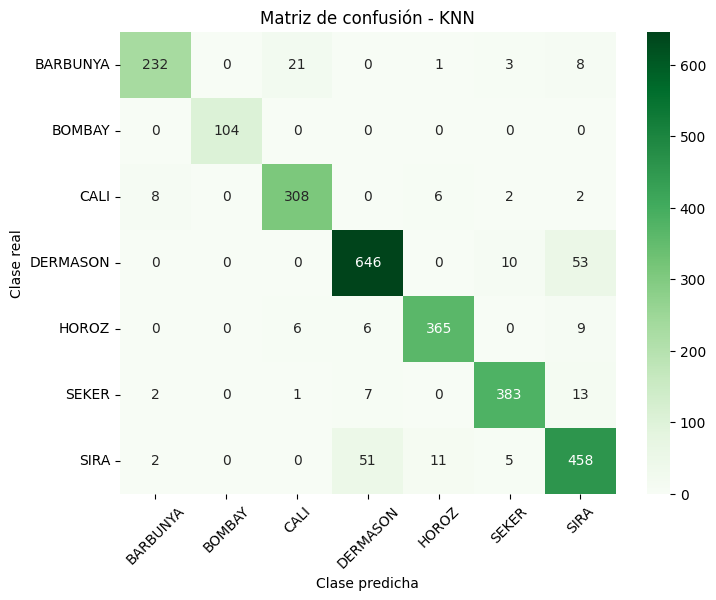

In [27]:
# Matriz de confusión KNN
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Matriz de confusión - KNN")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Interpretación del modelo KNN

KNN clasifica cada observación según las clases de sus vecinos más cercanos. En este dataset, donde las variables representan medidas de forma y tamaño, este enfoque resulta adecuado.

Si KNN obtiene un desempeño similar o superior a Logistic Regression, puede interpretarse que la cercanía entre observaciones en el espacio de variables es útil para distinguir las variedades de porotos.

## 6. Tuneo de hiperparámetros

En esta sección se modifica un hiperparámetro del modelo KNN: la cantidad de vecinos `n_neighbors`.

Se prueban distintos valores de `k` para observar cómo afecta el desempeño del modelo. Un valor de k muy bajo puede hacer que el modelo sea sensible al ruido, mientras que un valor muy alto puede hacerlo demasiado general.

In [28]:
# Prueba de distintos valores de k
resultados_k = []

for k in range(1, 22, 2):
    modelo = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    resultados_k.append({
        "k": k,
        "accuracy_test": accuracy_score(y_test, y_pred),
        "f1_macro_test": f1_score(y_test, y_pred, average="macro")
    })

df_resultados_k = pd.DataFrame(resultados_k)
df_resultados_k

,k,accuracy_test,f1_macro_test
0,1,0.898641,0.914113
1,3,0.915167,0.928536
2,5,0.916636,0.929259
3,7,0.913698,0.926532
4,9,0.916269,0.928868
5,11,0.918472,0.930954
6,13,0.918840,0.932222
7,15,0.918840,0.932523
8,17,0.918105,0.931326
9,19,0.917003,0.930178


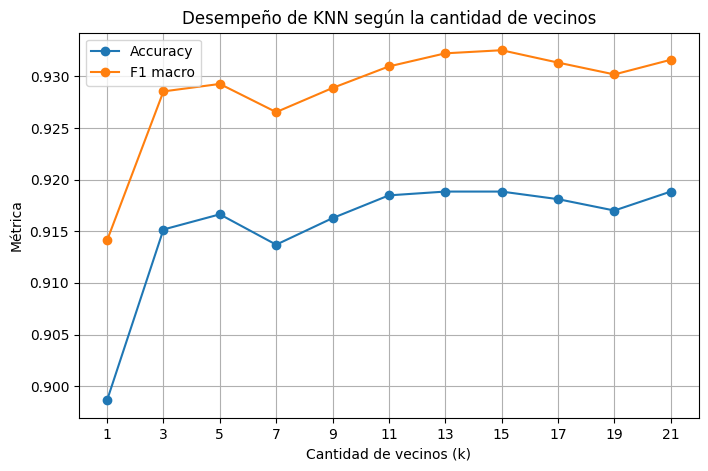

In [29]:
plt.figure(figsize=(8,5))
plt.plot(df_resultados_k["k"], df_resultados_k["accuracy_test"], marker="o", label="Accuracy")
plt.plot(df_resultados_k["k"], df_resultados_k["f1_macro_test"], marker="o", label="F1 macro")
plt.title("Desempeño de KNN según la cantidad de vecinos")
plt.xlabel("Cantidad de vecinos (k)")
plt.ylabel("Métrica")
plt.xticks(df_resultados_k["k"])
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Mejor valor de k según F1 macro
best_k = df_resultados_k.sort_values(by="f1_macro_test", ascending=False).iloc[0]["k"]
best_k = int(best_k)
best_k

15

In [31]:
# Entrenamiento final de KNN con el mejor k encontrado
knn_tuned_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

knn_tuned_model.fit(X_train, y_train)

y_train_pred_knn_tuned = knn_tuned_model.predict(X_train)
y_test_pred_knn_tuned = knn_tuned_model.predict(X_test)

metrics_knn_tuned = {
    "Modelo": f"KNN tuneado k={best_k}",
    "Accuracy train": accuracy_score(y_train, y_train_pred_knn_tuned),
    "Accuracy test": accuracy_score(y_test, y_test_pred_knn_tuned),
    "Precision macro test": precision_score(y_test, y_test_pred_knn_tuned, average="macro"),
    "Recall macro test": recall_score(y_test, y_test_pred_knn_tuned, average="macro"),
    "F1 macro test": f1_score(y_test, y_test_pred_knn_tuned, average="macro")
}

comparacion_modelos = pd.DataFrame([metrics_lr, metrics_knn, metrics_knn_tuned])
comparacion_modelos

,Modelo,Accuracy train,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Logistic Regression,0.926249,0.921410,0.935383,0.932149,0.933538
1,KNN default,0.941495,0.916636,0.932026,0.927059,0.929259
2,KNN tuneado k=15,0.933137,0.918840,0.935231,0.930585,0.932523


In [32]:
print(classification_report(
    y_test,
    y_test_pred_knn_tuned,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    BARBUNYA       0.97      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.96      0.94       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



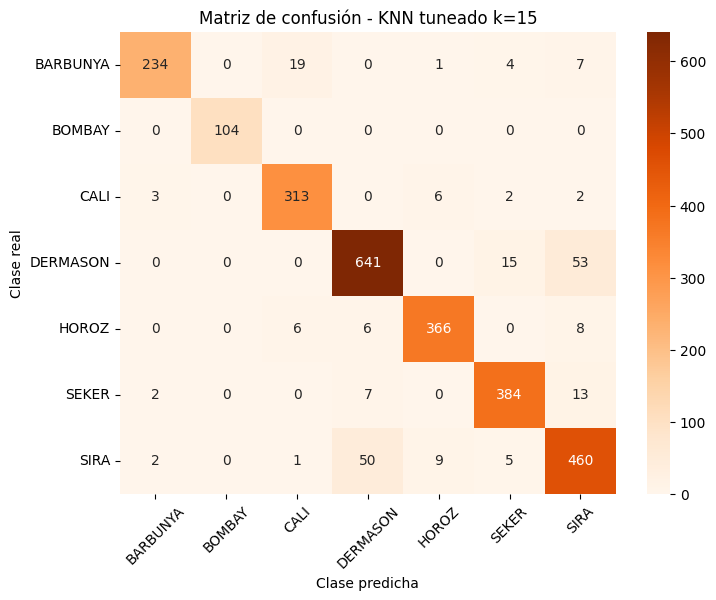

In [33]:
cm_knn_tuned = confusion_matrix(y_test, y_test_pred_knn_tuned)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_knn_tuned,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f"Matriz de confusión - KNN tuneado k={best_k}")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Interpretación del tuneo

Al modificar el valor de `k`, se observa cómo cambia el rendimiento del modelo. El objetivo es encontrar un equilibrio entre un modelo demasiado sensible a casos particulares y un modelo demasiado general.

El mejor valor de `k` se selecciona usando F1 macro, porque esta métrica considera el desempeño promedio en todas las clases y es más informativa que accuracy cuando las clases no están perfectamente balanceadas.

## 7. Bonus 2: comparación con class_weight='balanced'

Como el dataset no está completamente balanceado, se realiza una comparación entre Logistic Regression sin balanceo y Logistic Regression con `class_weight='balanced'`.

Este parámetro le da mayor peso a las clases con menos ejemplos durante el entrenamiento.

In [34]:
# Logistic Regression con class_weight='balanced'
log_reg_balanced_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"))
])

log_reg_balanced_model.fit(X_train, y_train)

y_test_pred_lr_balanced = log_reg_balanced_model.predict(X_test)

metrics_lr_balanced = {
    "Modelo": "Logistic Regression balanced",
    "Accuracy train": accuracy_score(y_train, log_reg_balanced_model.predict(X_train)),
    "Accuracy test": accuracy_score(y_test, y_test_pred_lr_balanced),
    "Precision macro test": precision_score(y_test, y_test_pred_lr_balanced, average="macro"),
    "Recall macro test": recall_score(y_test, y_test_pred_lr_balanced, average="macro"),
    "F1 macro test": f1_score(y_test, y_test_pred_lr_balanced, average="macro")
}

pd.DataFrame([metrics_lr, metrics_lr_balanced, metrics_knn, metrics_knn_tuned])

,Modelo,Accuracy train,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Logistic Regression,0.926249,0.921410,0.935383,0.932149,0.933538
1,Logistic Regression balanced,0.922024,0.917371,0.930961,0.931418,0.930744
2,KNN default,0.941495,0.916636,0.932026,0.927059,0.929259
3,KNN tuneado k=15,0.933137,0.918840,0.935231,0.930585,0.932523


In [35]:
print(classification_report(
    y_test,
    y_test_pred_lr_balanced,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.90      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.94      0.88      0.91       709
       HOROZ       0.96      0.95      0.96       386
       SEKER       0.92      0.95      0.94       406
        SIRA       0.83      0.89      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



### Interpretación

El uso de `class_weight='balanced'` busca mejorar el rendimiento en clases minoritarias. Si mejora el recall o el F1-score macro, significa que el modelo está clasificando mejor las clases con menos ejemplos. Si el accuracy baja levemente, puede ser aceptable porque el modelo deja de favorecer tanto a las clases mayoritarias.

## 8. Conclusiones

En este trabajo se aplicaron modelos de clasificación al dataset Dry Bean. El objetivo fue predecir el tipo de poroto a partir de variables geométricas extraídas de imágenes.

Primero se realizó un análisis exploratorio para conocer la estructura del dataset. Se observó que no había valores faltantes y que todas las variables predictoras eran numéricas. También se identificó que la variable objetivo tenía 7 clases y que la distribución no era perfectamente balanceada.

Luego se realizó el preprocesamiento: se separaron las variables predictoras y la variable objetivo, se codificó el target y se dividieron los datos en entrenamiento y prueba. Además, se aplicó escalado de variables porque tanto Logistic Regression como KNN pueden verse afectados por la escala de las features.

El primer modelo entrenado fue Logistic Regression. Este modelo obtuvo buenos resultados y permitió establecer una primera comparación. Luego se entrenó KNN, que resultó una elección adecuada porque clasifica a partir de la cercanía entre observaciones, algo razonable en un dataset donde los porotos se describen mediante forma y tamaño.

Finalmente, se realizó un tuneo del hiperparámetro `n_neighbors` en KNN. Esto permitió observar cómo cambia el desempeño del modelo al modificar la cantidad de vecinos considerados. La comparación final permitió elegir el modelo con mejor rendimiento según métricas como accuracy y F1 macro.

Como conclusión general, las características geométricas del dataset son útiles para clasificar los distintos tipos de porotos. El uso de métricas como F1 macro fue importante porque el dataset no estaba completamente balanceado.

## Referencias

- UCI Machine Learning Repository: Dry Bean Dataset.
- Scikit-learn documentation: LogisticRegression, KNeighborsClassifier, train_test_split, StandardScaler, classification_report.
- Pandas documentation.
- Matplotlib y Seaborn documentation.
- Asistencia de ChatGPT para corrección de errores, explicación de código e interpretaciones.